# Preparation

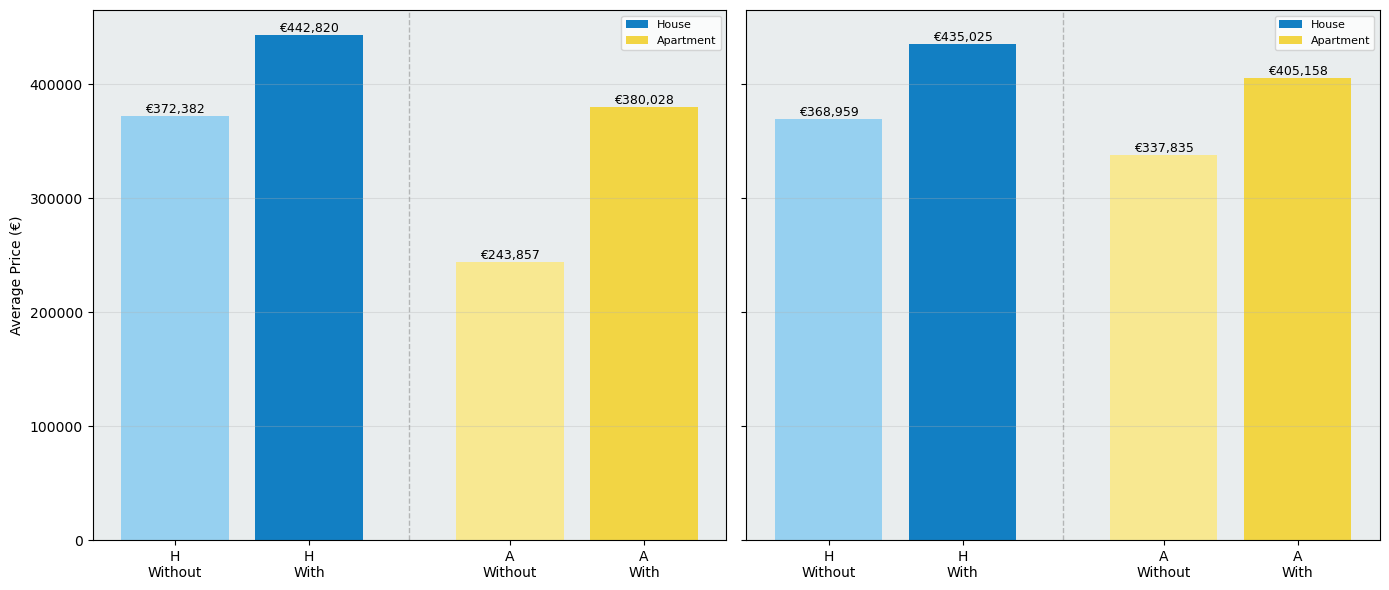

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

features = ['terrace', 'garden']
titles = ['Terrace', 'Garden']

for idx, (feature, title) in enumerate(zip(features, titles)):
    
    ax = axes[idx]

    # Calculate for houses
    house_with = dataset[(dataset.type == 'house') & (dataset[feature] == True)]['price'].mean()
    house_without = dataset[(dataset.type == 'house') & (dataset[feature] == False)]['price'].mean()

    # Calculate for apartments
    apt_with = dataset[(dataset.type == 'apartment') & (dataset[feature] == True)]['price'].mean()
    apt_without = dataset[(dataset.type == 'apartment') & (dataset[feature] == False)]['price'].mean()

    # Bar positions
    x_positions = [0, 1, 2.5, 3.5]
    categories = ['H\nWithout', 'H\nWith', 'A\nWithout', 'A\nWith']
    values = [house_without, house_with, apt_without, apt_with]

    colors = ['#96D0F0', '#127FC3', '#F8E891', "#F2D544"]

    bars = ax.bar(x_positions, values, color=colors, alpha=1, width=0.8)

    # Value labels
    for bar in bars:
        height = bar.get_height()
        if not np.isnan(height):
            ax.text(
                bar.get_x() + bar.get_width()/2.,
                height,
                f'€{height:,.0f}',
                ha='center',
                va='bottom',
                fontsize=9
            )

    ax.set_xticks(x_positions)
    ax.set_xticklabels(categories)

    # Separation line
    ax.axvline(x=1.75, color='gray', linestyle='--', linewidth=1, alpha=0.5)

    if idx == 0:
        ax.set_ylabel("Average Price (€)")
    # ax.set_title(title)
    ax.ticklabel_format(style='plain', axis='y')
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_facecolor("#E9EDEE")

    # Legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#127FC3', label='House'),
        Patch(facecolor='#F2D544', label='Apartment')
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=8)

# plt.suptitle("Impact of Features on Price: Houses vs Apartments", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
# os.makedirs("plots", exist_ok=True)
fig.savefig("plots/terrace_garden.png", bbox_inches="tight")

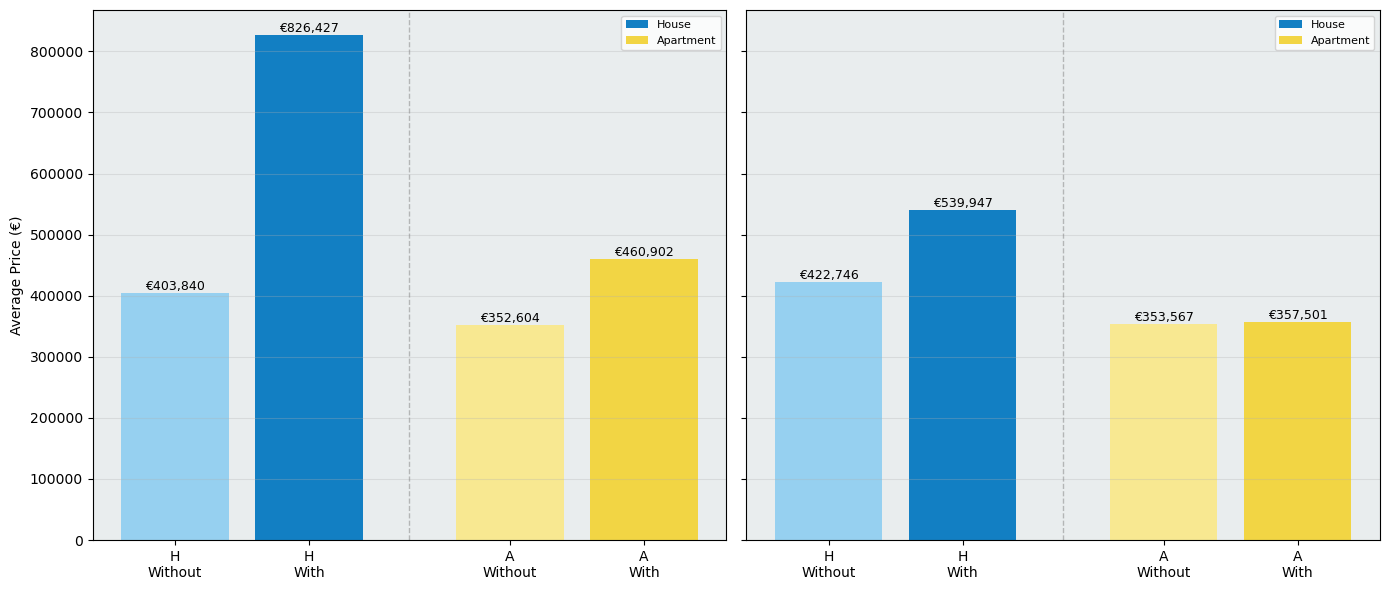

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

features = ['pool', 'furnished']
titles = ['Pool', 'Furnished']

for idx, (feature, title) in enumerate(zip(features, titles)):
    
    ax = axes[idx]

    # Calculate for houses
    house_with = dataset[(dataset.type == 'house') & (dataset[feature] == True)]['price'].mean()
    house_without = dataset[(dataset.type == 'house') & (dataset[feature] == False)]['price'].mean()

    # Calculate for apartments
    apt_with = dataset[(dataset.type == 'apartment') & (dataset[feature] == True)]['price'].mean()
    apt_without = dataset[(dataset.type == 'apartment') & (dataset[feature] == False)]['price'].mean()

    # Bar positions
    x_positions = [0, 1, 2.5, 3.5]
    categories = ['H\nWithout', 'H\nWith', 'A\nWithout', 'A\nWith']
    values = [house_without, house_with, apt_without, apt_with]

    colors = ['#96D0F0', '#127FC3', '#F8E891', "#F2D544"]

    bars = ax.bar(x_positions, values, color=colors, alpha=1, width=0.8)

    # Value labels
    for bar in bars:
        height = bar.get_height()
        if not np.isnan(height):
            ax.text(
                bar.get_x() + bar.get_width()/2.,
                height,
                f'€{height:,.0f}',
                ha='center',
                va='bottom',
                fontsize=9
            )

    ax.set_xticks(x_positions)
    ax.set_xticklabels(categories)

    # Separation line
    ax.axvline(x=1.75, color='gray', linestyle='--', linewidth=1, alpha=0.5)

    if idx == 0:
        ax.set_ylabel("Average Price (€)")
    # ax.set_title(title)
    ax.ticklabel_format(style='plain', axis='y')
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_facecolor("#E9EDEE")

    # Legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#127FC3', label='House'),
        Patch(facecolor='#F2D544', label='Apartment')
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=8)

# plt.suptitle("Impact of Features on Price: Houses vs Apartments", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
fig.savefig("plots/pool_furnished.png", bbox_inches="tight")

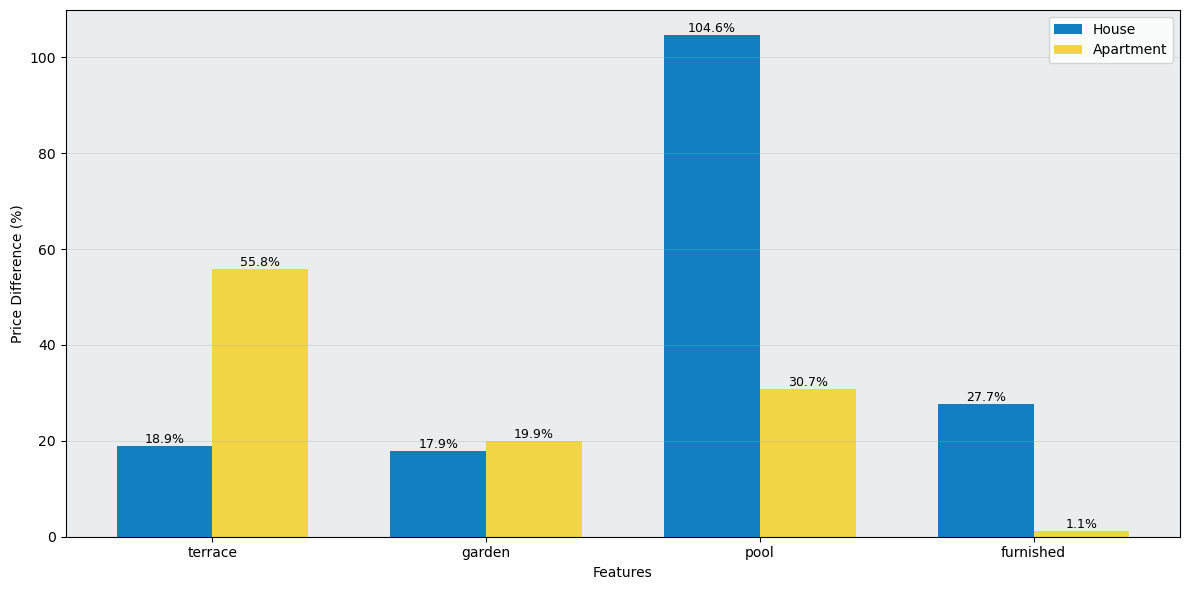

In [49]:
fig, ax = plt.subplots(figsize=(12, 6))

features = ['terrace', 'garden', 'pool', 'furnished']
x = np.arange(len(features))
width = 0.35

house_diffs = []
apt_diffs = []

for feature in features:
    # Houses
    house_with = dataset[(dataset.type == 'house') & (dataset[feature] == True)]['price'].mean()
    house_without = dataset[(dataset.type == 'house') & (dataset[feature] == False)]['price'].mean()
    house_diff = ((house_with - house_without) / house_without) * 100
    house_diffs.append(house_diff)
    
    # Apartments
    apt_with = dataset[(dataset.type == 'apartment') & (dataset[feature] == True)]['price'].mean()
    apt_without = dataset[(dataset.type == 'apartment') & (dataset[feature] == False)]['price'].mean()
    apt_diff = ((apt_with - apt_without) / apt_without) * 100
    apt_diffs.append(apt_diff)

# Create bars
bars1 = ax.bar(x - width/2, house_diffs, width, label='House', color='#127FC3', alpha=1)
bars2 = ax.bar(x + width/2, apt_diffs, width, label='Apartment', color='#F2D544', alpha=1)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if not np.isnan(height):
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.1f}%', ha='center', va='bottom' if height > 0 else 'top', fontsize=9)

ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.set_xlabel('Features')
ax.set_ylabel('Price Difference (%)')
# ax.set_title('Percentage Price Impact of Features: Houses vs Apartments')
ax.set_xticks(x)
ax.set_xticklabels(features)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_facecolor("#E9EDEE")

plt.tight_layout()
plt.show()
fig.savefig("plots/percentage_price_impact_of_terrace_garden_pool_furnished.png", bbox_inches="tight")

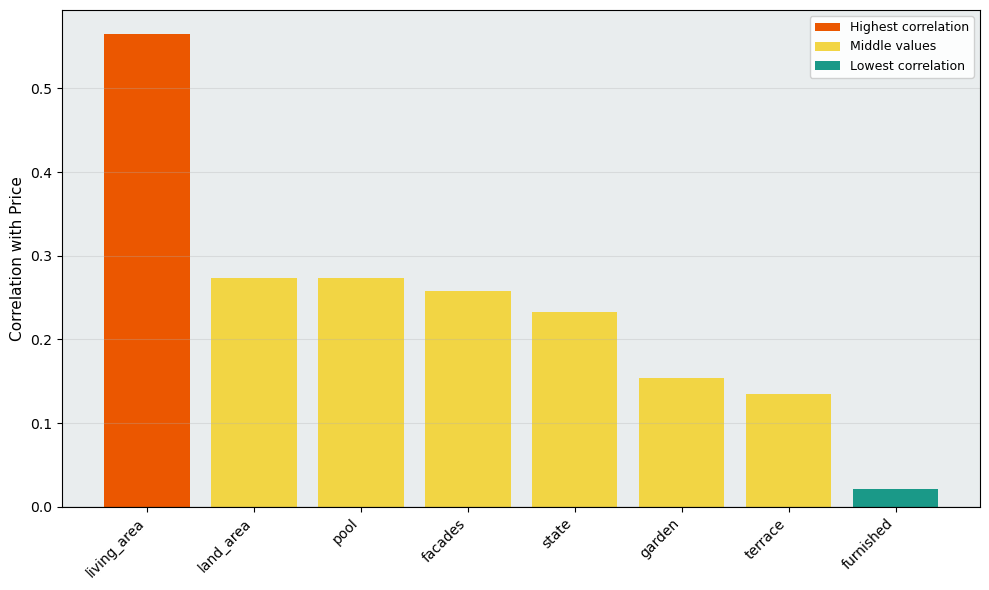

In [53]:
numerical_cols = ['price', 'living_area', 'land_area', 'facades', 'state']
df_numeric = dataset[numerical_cols].copy()

# Convert boolean columns to numeric (0/1) for correlation
df_numeric['furnished'] = dataset['furnished'].astype(int)
df_numeric['terrace'] = dataset['terrace'].astype(int)
df_numeric['garden'] = dataset['garden'].astype(int)
df_numeric['pool'] = dataset['pool'].astype(int)

# Calculate correlations with price
correlations = df_numeric.corr()['price'].drop('price').sort_values(ascending=False)

# Create color list - highest value gets one color, lowest gets another
colors = []
for i, val in enumerate(correlations.values):
    if i == 0:  # highest
        colors.append('#EB5700')  # blue
    elif i == len(correlations) - 1:  # lowest
        colors.append('#1A9988')  # orange
    else:
        colors.append('#F2D544')  # yellow for middle values

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))  # create fig and ax

bars = ax.bar(range(len(correlations)), correlations.values, color=colors)

ax.set_xticks(range(len(correlations)))
ax.set_xticklabels(correlations.index, rotation=45, ha='right')
ax.set_ylabel('Correlation with Price', fontsize=11)

ax.axhline(y=0, color='black', linewidth=0.8, linestyle='-')
ax.grid(axis='y', alpha=0.3)

# Set background color
ax.set_facecolor("#E9EDEE")

# Add legend inside the plot at top right
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#EB5700', label='Highest correlation'),
    Patch(facecolor='#F2D544', label='Middle values'),
    Patch(facecolor='#1A9988', label='Lowest correlation')
]
plt.legend(handles=legend_elements, loc='upper right', fontsize=9, frameon=True, 
           framealpha=0.9, fancybox=True)

plt.tight_layout()
plt.show()
plt.show()
fig.savefig("plots/percentage_price_impact_of_terrace_garden_pool_furnished.png", bbox_inches="tight")

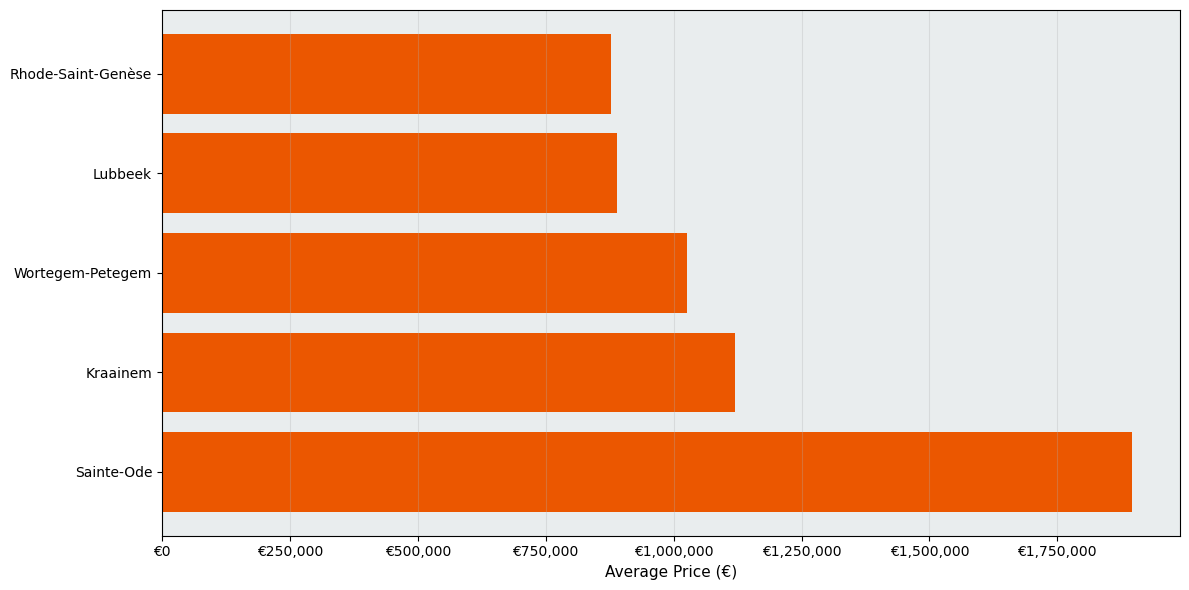

In [55]:
# Simple box plot for top 5 most expensive vs cheapest municipalities
# Get average price by municipality
municipality_avg = dataset.groupby('municipality')['price'].mean().sort_values(ascending=False)

# Plot top 5 most expensive and bottom 5 cheapest
top_5 = municipality_avg.head(5)
bottom_5 = municipality_avg.tail(5)
fig, ax = plt.subplots(figsize=(12, 6))

# Top 5 most expensive
top_bars = ax.barh(range(len(top_5)), top_5.values, color='#EB5700')
ax.set_yticks(range(len(top_5)))
ax.set_yticklabels(top_5.index)
ax.set_xlabel('Average Price (€)', fontsize=11)
ax.set_facecolor("#E9EDEE")

# ax.set_title('Top 5 Most Expensive Municipalities', fontweight='bold', fontsize=12)

# Format x-axis to show regular numbers (not scientific notation)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'€{x:,.0f}'))

ax.grid(axis='x', alpha=0.3)

# Adjust layout to prevent overlap
plt.subplots_adjust(hspace=0.3)  # Add space between the two plots
plt.tight_layout()
plt.show()
fig.savefig("plots/top5_expensive.png", bbox_inches="tight")

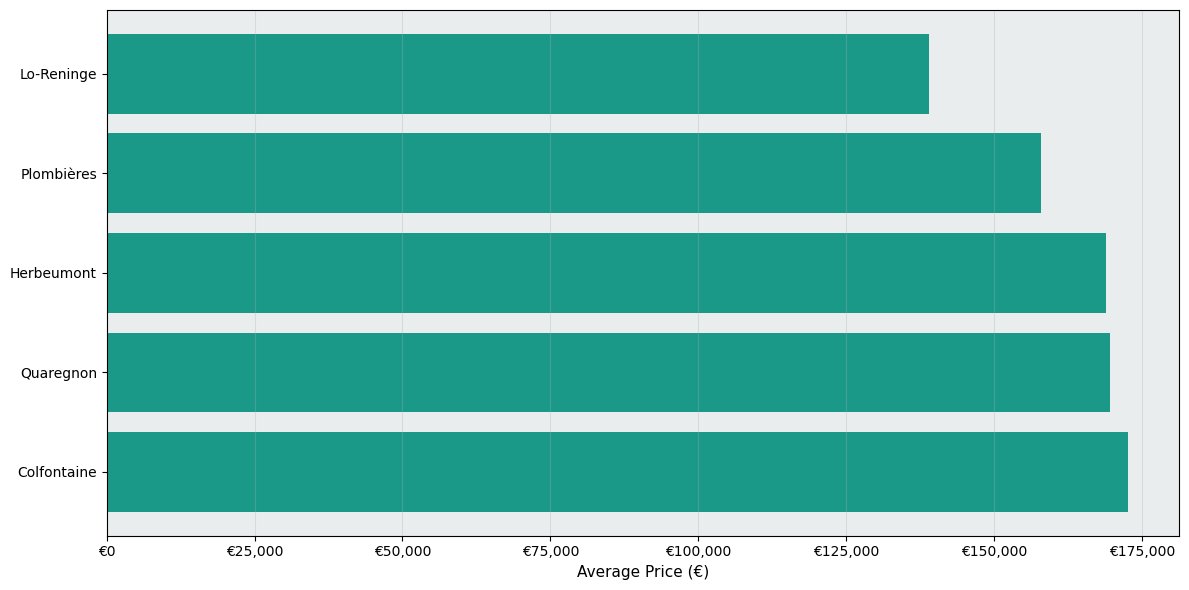

In [56]:
municipality_avg = dataset.groupby('municipality')['price'].mean().sort_values(ascending=False)

# Plot top 5 most expensive and bottom 5 cheapest
top_5 = municipality_avg.head(5)
bottom_5 = municipality_avg.tail(5)
fig, ax = plt.subplots(figsize=(12, 6))
bottom_bars = ax.barh(range(len(bottom_5)), bottom_5.values, color='#1A9988')
ax.set_yticks(range(len(bottom_5)))
ax.set_yticklabels(bottom_5.index)
ax.set_xlabel('Average Price (€)', fontsize=11)
ax.set_facecolor("#E9EDEE")
# ax.set_title('Top 5 Cheapest Municipalities', fontweight='bold', fontsize=12)

# Format x-axis to show regular numbers (not scientific notation)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'€{x:,.0f}'))

ax.grid(axis='x', alpha=0.3)



# Adjust layout to prevent overlap
plt.subplots_adjust(hspace=0.3)  # Add space between the two plots
plt.tight_layout()
plt.show()
fig.savefig("plots/top5_cheapest.png", bbox_inches="tight")